### Mapeando la funcion de probabilidad


\begin{equation}
    p(\widetilde{X}) = p(\widetilde{E})\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

In [1]:
import numpy as np
from Utils import (
    compute_functions, 
    compute_state_vector, 
    Kepler, OrbitTrasformations, 
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_E_to_X, 
    trasformation_X_to_E,
    P_E
    )
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import warnings
%load_ext autoreload 
%autoreload 2

In [2]:
cu = CanonicalUnits()
deg = cu.deg
AU_m = cu.AU_m #m
M_sun = cu.M_sun
G = cu.G # m^3 / (kg s^2)
year = cu.year #s
mu = cu.mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
def jacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> np.array:
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D', 'F', 'G'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    F = functions['F']
    G = functions['G']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_z = state_vector[2]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)
    partial_a_vz = -state_vector[5]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_z, partial_a_vx, partial_a_vy, partial_a_vz]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        drAde*F+drBde*G,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D,
        dvAde*F+dvBde*G
    ])

    #partial i
    partial_i_x = state_vector[2]*np.sin(Omega)
    partial_i_y = -state_vector[2]*np.cos(Omega)
    partial_i_z = -state_vector[0]*np.sin(Omega) + state_vector[1]*np.cos(Omega)

    partial_i_vx = state_vector[5]*np.sin(Omega)
    partial_i_vy = -state_vector[5]*np.cos(Omega)
    partial_i_vz = -state_vector[3]*np.sin(Omega) + state_vector[4]*np.cos(Omega)

    partial_i = [partial_i_x, partial_i_y, partial_i_z, partial_i_vx, partial_i_vy, partial_i_vz]

    #partial Omega
    partial_Omega_x = -state_vector[1]
    partial_Omega_y = state_vector[0]
    partial_Omega_z = 0

    partial_Omega_vx = -state_vector[4]
    partial_Omega_vy = state_vector[3]
    partial_Omega_vz = 0

    partial_Omega = [partial_Omega_x, partial_Omega_y, partial_Omega_z, partial_Omega_vx, partial_Omega_vy, partial_Omega_vz]

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_z = state_vector[0]*np.sin(i)*np.cos(Omega) + state_vector[1]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)
    partial_w_vz = state_vector[3]*np.sin(i)*np.cos(Omega) + state_vector[4]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_z, partial_w_vx, partial_w_vy, partial_w_vz]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_z = (1/n) * state_vector[5]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]
    partial_M_vz = factor * state_vector[2]

    partial_M = [partial_M_x, partial_M_y, partial_M_z, partial_M_vx, partial_M_vy, partial_M_vz]

    J = np.zeros((6,6))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_i
    J[:,3] = partial_Omega
    J[:,4] = partial_w
    J[:,5] = partial_M
    
    return J

In [4]:
a = np.random.uniform(0, 2)
e = np.random.uniform(0, 1)
i = np.random.uniform(0, np.pi)
Omega = np.random.uniform(0, 2*np.pi)
w = np.random.uniform(0, 2*np.pi)
M = np.random.uniform(0, 2*np.pi)
q = a*(1-e)

print('orbital elements: ', a, e, i, Omega, w, M)

orbital elements:  1.2435841232485139 0.12083779224803437 0.9855294663639896 4.411194343498304 0.8352481623318945 0.06670123318383857


In [5]:
x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
print('state vector: ', x, y, z, vx, vy, vz)

state vector:  0.26303837020105425 -0.7747477097760228 0.7258467257875487 3.54660353853473 4.163327721257686 3.2469820397612748


In [ ]:
def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            if det == 0 or not np.isfinite(det):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx]))
            else:
                inv_det = 1.0/det  
            P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape)


In [ ]:
            with np.errstate(divide='ignore', invalid='ignore'):
                detJ = np.linalg.det(J)
                if detJ == 0 or not np.isfinite(detJ):
                    problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],
                                        vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                    P.flat[idx] = np.nan
                else:
                    det = 1.0 / detJ
                    P.flat[idx] = P_E() * abs(det)

In [7]:
P_X(x, y, z, vx, vy, vz)

4.603812219100729e-05

In [8]:
x_inf, y_inf, z_inf, vx_inf, vy_inf, vz_inf = trasformation_E_to_X(0.001, 0.001, 0.001, 0.001, 0.001, 0.001, mu)
print('state vector: ', x_inf, y_inf, z_inf, vx_inf, vy_inf, vz_inf)

state vector:  0.0009989954990018764 2.998994997164481e-06 1.999998831830794e-09 -0.5969494139698999 198.9160693997896 0.19891663319662647


In [9]:
x_max, y_max, z_max, vx_max, vy_max, vz_max = trasformation_E_to_X(1.3, 0.999, np.pi, 2*np.pi, 2*np.pi, 2*np.pi, mu)
print('state vector: ', x_max, y_max, z_max, vx_max, vy_max, vz_max)

state vector:  0.0013000000000000012 0.0 -3.8993754349208336e-35 0.0 -246.4180226001074 3.017750426294417e-14


In [10]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

x_lim = (c_x - widths[0]/2, c_x + widths[0]/2)
y_lim = (c_y - widths[1]/2, c_y + widths[1]/2)
z_lim = (c_z - widths[2]/2, c_z + widths[2]/2)
vx_lim = (c_x - widths[3]/2, c_x + widths[3]/2)
vy_lim = (c_y - widths[4]/2, c_y + widths[4]/2)
vz_lim = (c_z - widths[5]/2, c_z + widths[5]/2)


In [11]:
x_lim

(0.9, 1.1)

### Evaluating in the integral limits 

In [12]:
X = np.linspace(x_lim[0], x_lim[1], 100)
Y = np.linspace(y_lim[0], y_lim[1], 100)
Z = np.linspace(z_lim[0], z_lim[1], 100)
VX = np.linspace(vx_lim[0], vx_lim[1], 100)
VY = np.linspace(vy_lim[0], vy_lim[1], 100)
VZ = np.linspace(vz_lim[0], vz_lim[1], 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla)

P_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY = P_X_vectorized(x=zero_vector + 1.0, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ = P_X_vectorized(x=zero_vector + 1.0, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

C:\Users\aguju\AppData\Local\Temp\ipykernel_31604\277835278.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


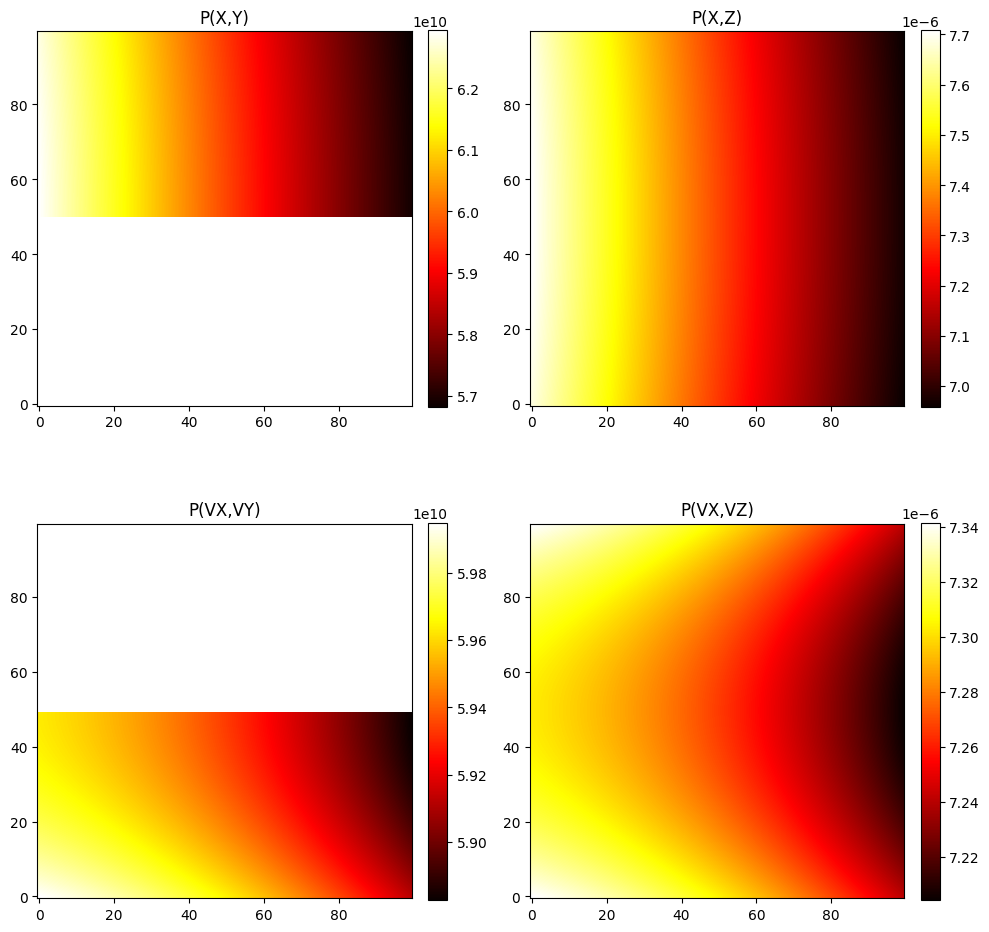

In [13]:
P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

In [14]:
X = np.linspace(0.001, 2, 100)
Y = np.linspace(0.001, 2, 100)
Z = np.linspace(0.001, 0.4, 100)
VX = np.linspace(-5, -0.9, 100)
VY = np.linspace(-5, -0.9, 100)
VZ = np.linspace(0.001, 0.8, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla)

P_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY = P_X_vectorized(x=zero_vector + 1.0, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ = P_X_vectorized(x=zero_vector + 1.0, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

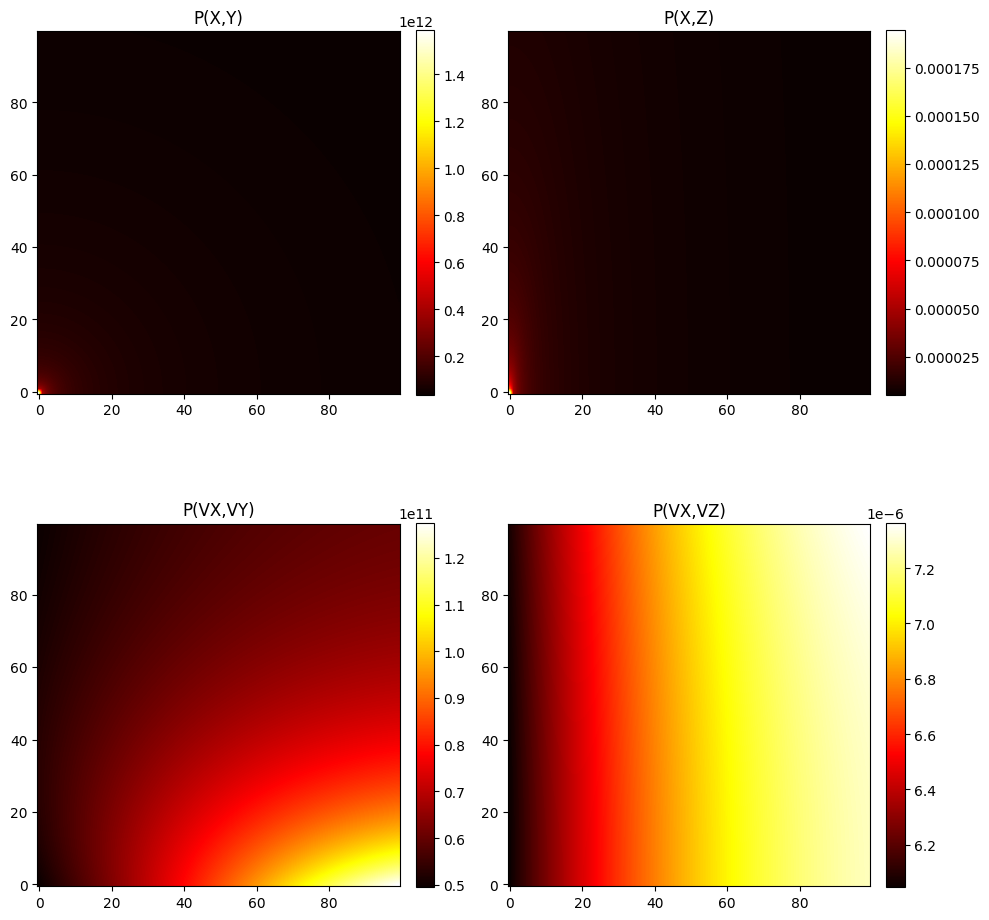

In [15]:
P = [P_XY, P_XZ, P_VXY, P_VXZ]
titles = ["P(X,Y)", "P(X,Z)", "P(VX,VY)", "P(VX,VZ)",]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(P[i],
                   origin='lower',
                   cmap='hot',
                   interpolation='bilinear')

    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # barra individual

plt.tight_layout()
plt.show()

## Tomar valores en cajas de posicion y velocidad que tengan sentido fisico e ir ampliando ejemplo: x = 1, vx = (0.1, 0.1) vy = 28 km/s - 32 km/s  y sus inversos deberian dar tambien

Hacer rutinas entregables 

Hacer un interactivo de python de barras x, y, z, vx, vy, vz y como se ve eso en orbitas de los planetas

singularidades en el jacobiano??

Hacer que las singularidades (que las definimos desde la fisica) valgan cero para que no contribuyan con la integral 

Preguntarle a chato, a cursor

In [20]:
X = np.linspace(0.8, 1.2, 100)
VY = np.linspace(5.8, 6.2, 100)

X_malla, VY_malla = np.meshgrid(X, VY)
P_XY = P_X_vectorized(x=X_malla, y=zero_vector, z=zero_vector, vx=zero_vector + 0.1, vy=VY_malla, vz=zero_vector, mu=mu)


0.8 0.0 0.0 0.1 5.8 0.0
0.8040404040404041 0.0 0.0 0.1 5.8 0.0
0.8080808080808082 0.0 0.0 0.1 5.8 0.0
0.8121212121212121 0.0 0.0 0.1 5.8 0.0
0.8161616161616162 0.0 0.0 0.1 5.8 0.0
0.8202020202020203 0.0 0.0 0.1 5.8 0.0
0.8242424242424243 0.0 0.0 0.1 5.8 0.0
0.8282828282828283 0.0 0.0 0.1 5.8 0.0
0.8323232323232324 0.0 0.0 0.1 5.8 0.0
0.8363636363636364 0.0 0.0 0.1 5.8 0.0
0.8404040404040405 0.0 0.0 0.1 5.8 0.0
0.8444444444444444 0.0 0.0 0.1 5.8 0.0
0.8484848484848485 0.0 0.0 0.1 5.8 0.0
0.8525252525252526 0.0 0.0 0.1 5.8 0.0
0.8565656565656566 0.0 0.0 0.1 5.8 0.0
0.8606060606060606 0.0 0.0 0.1 5.8 0.0
0.8646464646464647 0.0 0.0 0.1 5.8 0.0
0.8686868686868687 0.0 0.0 0.1 5.8 0.0
0.8727272727272728 0.0 0.0 0.1 5.8 0.0
0.8767676767676768 0.0 0.0 0.1 5.8 0.0
0.8808080808080808 0.0 0.0 0.1 5.8 0.0
0.8848484848484849 0.0 0.0 0.1 5.8 0.0
0.888888888888889 0.0 0.0 0.1 5.8 0.0
0.8929292929292929 0.0 0.0 0.1 5.8 0.0
0.896969696969697 0.0 0.0 0.1 5.8 0.0
0.901010101010101 0.0 0.0 0.1 5.8 0.0
0.90

C:\Users\aguju\AppData\Local\Temp\ipykernel_31604\2752504673.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


0.8242424242424243 0.0 0.0 0.1 5.82020202020202 0.0
0.8282828282828283 0.0 0.0 0.1 5.82020202020202 0.0
0.8323232323232324 0.0 0.0 0.1 5.82020202020202 0.0
0.8363636363636364 0.0 0.0 0.1 5.82020202020202 0.0
0.8404040404040405 0.0 0.0 0.1 5.82020202020202 0.0
0.8444444444444444 0.0 0.0 0.1 5.82020202020202 0.0
0.8484848484848485 0.0 0.0 0.1 5.82020202020202 0.0
0.8525252525252526 0.0 0.0 0.1 5.82020202020202 0.0
0.8565656565656566 0.0 0.0 0.1 5.82020202020202 0.0
0.8606060606060606 0.0 0.0 0.1 5.82020202020202 0.0
0.8646464646464647 0.0 0.0 0.1 5.82020202020202 0.0
0.8686868686868687 0.0 0.0 0.1 5.82020202020202 0.0
0.8727272727272728 0.0 0.0 0.1 5.82020202020202 0.0
0.8767676767676768 0.0 0.0 0.1 5.82020202020202 0.0
0.8808080808080808 0.0 0.0 0.1 5.82020202020202 0.0
0.8848484848484849 0.0 0.0 0.1 5.82020202020202 0.0
0.888888888888889 0.0 0.0 0.1 5.82020202020202 0.0
0.8929292929292929 0.0 0.0 0.1 5.82020202020202 0.0
0.896969696969697 0.0 0.0 0.1 5.82020202020202 0.0
0.901010101010

In [17]:
def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

In [ ]:
P_X(0.8, 0.1, 0.0, 0.1, 5.8, 0.0)0.8202020202020203 0.0 0.0 0.1 5.82020202020202 0.0

C:\Users\aguju\AppData\Local\Temp\ipykernel_31604\3047769587.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


inf